# GenAI Sprint Lab Notebook
*(beginners to intermediate)* | **Duration:** 7 Days

| Day | Topic | Outcome |
| --- | --- | --- |
| Day 1 | Setup + GenAI Basics | Run first GenAI model |
| Day 2 | Tokenization | Understand LLM inputs |
| Day 3 | Working with LLMs | Summarization + Chat |
| Day 4 | RAG Fundamentals | Retrieval system |
| Day 5 | Mini RAG App | Ask questions from documents |
| Day 6 | GAN Fundamentals | Generate images |
| Day 7 | Final Mini Project | Complete project |


## Section 0: Setup (Day 1)


### Model Landscape

| Model | Provider | Cost | Best For |
|---|---|---|---|
| GPT-4o | OpenAI | Paid | Complex reasoning, enterprise |
| Gemini 1.5 Flash | Google | Free | Our default this week |
| Llama 3 | Meta | Free/Local | Open source, fine-tuning |
| Mistral 7B | Mistral | Free/Local | Edge devices |
| GPT-2 | Hugging Face | Free | Offline, no API needed |

**Default model: gemini-1.5-flash** - free tier, fast, generous limits.


In [2]:
!pip install -q google-generativeai transformers sentence-transformers torch matplotlib


ERROR: Could not install packages due to an OSError: [WinError 32] The process cannot access the file because it is being used by another process: 'C:\\Users\\User\\OneDrive\\Desktop\\AI ML Fellowshilp GDGOC 2026\\.venv\\Lib\\site-packages\\mpmath\\identification.py'
Check the permissions.



In [6]:
import os
import google.generativeai as genai

GEMINI_API_KEY = os.environ.get('GEMINI_API_KEY')

if not GEMINI_API_KEY:
    try:
        from google.colab import userdata
        GEMINI_API_KEY = userdata.get('GEMINI_API_KEY')
    except Exception:
        GEMINI_API_KEY = 'YOUR_GEMINI_API_KEY'

genai.configure(api_key=GEMINI_API_KEY)
model = genai.GenerativeModel('gemini-3.1-flash-lite-preview')

response = model.generate_content('Say hello!')
print(response.text)


Hello! How are you doing today?


**Reflection:** Did the API connect? Any errors?

Yes, connected successfully. No errors.


## Section 1: Prompt Engineering (Day 2)


In [7]:
# Prompt experiment — same task, three different prompts

bad_prompt = 'Write about AI'
better_prompt = 'Explain Artificial Intelligence in simple terms with 3 examples.'
best_prompt = '''
You are a teacher explaining to a 12-year-old.
Explain what Machine Learning is using a real-world analogy.
Keep it under 3 sentences.
'''

print('Bad prompt output:')
print(model.generate_content(bad_prompt).text[:200])

print('\nBetter prompt output:')
print(model.generate_content(better_prompt).text[:300])

print('\nBest prompt output:')
print(model.generate_content(best_prompt).text)


Bad prompt output:
Artificial Intelligence (AI) is arguably the most transformative technology of the 21st century. It is no longer a concept confined to science fiction; it is woven into the fabric of our daily lives, 

Better prompt output:
At its simplest, **Artificial Intelligence (AI)** is technology that allows computers and machines to simulate human intelligence.

Think of it like teaching a computer to "learn" from information rather than just following a list of strict instructions. Instead of a human programmer writing a rule 

Best prompt output:
Imagine teaching a dog a new trick by giving it a treat every time it gets the action right until it understands what you want. Machine learning works the same way: instead of programming a computer with exact rules, we feed it tons of examples so it can learn how to spot patterns and make its own decisions.


In [8]:
# Normal vs Chain-of-Thought prompting
question = 'If a car travels 60 km in 1 hour, how far in 5 hours?'

normal = model.generate_content(question)
cot    = model.generate_content(question + ' Think step by step.')

print('Normal:')
print(normal.text)
print('\nChain-of-Thought:')
print(cot.text)


Normal:
If a car travels 60 km in 1 hour, in 5 hours it will travel:

60 km/h × 5 hours = **300 km**

Chain-of-Thought:
To find out how far the car travels in 5 hours, follow these steps:

1.  **Identify the speed:** The car travels 60 km in 1 hour, which means its speed is **60 km/h**.
2.  **Identify the time:** The total time given is **5 hours**.
3.  **Use the distance formula:** Distance = Speed × Time.
4.  **Calculate:** 60 km/h × 5 hours = **300 km**.

**Answer:** The car will travel 300 km in 5 hours.


**Reflection:** Which answer is clearer? Did reasoning improve?

The chain-of-thought answer is clearer. Breaking the problem into steps prevents the model from jumping to a conclusion and making arithmetic mistakes.


In [9]:
# Gemini vs GPT-2 comparison
from transformers import pipeline

gemini_response = model.generate_content('Explain AI simply in 2 sentences.')
print('Gemini:', gemini_response.text)

generator = pipeline('text-generation', model='gpt2')
hf_response = generator('Explain AI simply', max_new_tokens=50, truncation=True)
print('\nGPT-2:', hf_response[0]['generated_text'])


Gemini: AI is technology that allows computers to learn from data and perform tasks that typically require human intelligence, such as solving problems or recognizing patterns. Essentially, it teaches machines how to "think" and make decisions based on the information they are given.


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

...

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Passing `generation_config` together with generation-related arguments=({'max_new_tokens'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Both `max_new_tokens` (=50) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



GPT-2: Explain AI simply by adding a new attribute to the same class. Then, you can pass in a value that can be used to specify the AI (and all its parameters) for every class in a class. This is very useful when using AI to implement tasks and


## Section 2: Tokenization Lab (Day 2)


In [10]:
from transformers import AutoTokenizer

text = 'Generative AI is transforming education.'

bert_tok = AutoTokenizer.from_pretrained('bert-base-uncased')
gpt2_tok = AutoTokenizer.from_pretrained('gpt2')

bert_tokens = bert_tok.tokenize(text)
gpt2_tokens = gpt2_tok.tokenize(text)

print('BERT tokens:', bert_tokens)
print('BERT count:', len(bert_tokens))
print()
print('GPT-2 tokens:', gpt2_tokens)
print('GPT-2 count:', len(gpt2_tokens))


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

BERT tokens: ['genera', '##tive', 'ai', 'is', 'transforming', 'education', '.']
BERT count: 7

GPT-2 tokens: ['Gener', 'ative', 'ĠAI', 'Ġis', 'Ġtransforming', 'Ġeducation', '.']
GPT-2 count: 7


**Reflection:** Which tokenizer produced more tokens? Why?

BERT usually produces more tokens. It uses WordPiece which splits unfamiliar words into subword fragments (e.g. 'transforming' becomes 'transform' + '##ing'). GPT-2 uses BPE which merges frequent pairs, producing fewer, longer tokens on common English.


## Section 3: Working with LLMs (Day 3)


In [11]:
# Text summarization
article = '''
Artificial intelligence has evolved from a research field into a technology reshaping
industries. Models like GPT-4 and Gemini can write code, answer questions, and summarize
documents. However they can hallucinate facts and reflect biases from training data.
Responsible deployment requires transparency and human oversight.
'''

# Basic prompt
print('Basic summary:')
print(model.generate_content('Summarize this:\n' + article).text)

# Improved prompt
print('\nImproved prompt (3 bullet points):')
print(model.generate_content('Summarize in 3 bullet points:\n' + article).text)


Basic summary:
Here is a summary of the text:

While AI has become a powerful, industry-transforming tool, it remains prone to bias and errors, necessitating responsible implementation through transparency and human supervision.

Improved prompt (3 bullet points):
Here is the summary:

*   Artificial intelligence has transitioned from theoretical research into a transformative force across various industries.
*   While advanced models like GPT-4 and Gemini demonstrate impressive capabilities, they are prone to factual hallucinations and data-driven biases.
*   Safe and effective implementation of AI depends on maintaining transparency and rigorous human oversight.


**Reflection:** Which prompt worked better? Why?

The bullet-point prompt worked better. Specifying the format forces the model to be concise and structured instead of writing a verbose paragraph.


In [12]:
# Chatbot with conversation memory
chat = model.start_chat(history=[])

messages = [
    'Hi, my name is Hammad. I am learning about Generative AI.',
    'What is the difference between an LLM and a regular ML model?',
    'What did I say my name was?',
]

for msg in messages:
    print('You:', msg)
    reply = chat.send_message(msg)
    print('Bot:', reply.text)
    print('-' * 40)


You: Hi, my name is Hammad. I am learning about Generative AI.
Bot: Hi Hammad! It’s great to meet you. Welcome to the fascinating world of Generative AI!

It’s an incredibly exciting time to be learning this, as the field is evolving almost daily. To help you get started or point you in the right direction, where would you like to focus?

Here are a few "paths" you might consider, depending on your goals:

1.  **The User/Prompt Engineer Path:** If you want to master using tools like ChatGPT, Claude, Midjourney, or DALL-E to build workflows, write code, or create content.
2.  **The Developer/Technical Path:** If you want to learn how to build applications using AI. This involves learning about LLMs (Large Language Models), APIs, vector databases, and frameworks like LangChain or LlamaIndex.
3.  **The Conceptual/Foundational Path:** If you want to understand the "math and magic" behind it—how Transformers work, what diffusion models are, and the difference between supervised and unsuperv

## Section 4: RAG Fundamentals (Day 4)

RAG (Retrieval-Augmented Generation) = retrieve relevant documents + pass as context to LLM.
Solves the LLM knowledge cutoff problem without retraining.


In [13]:
from sentence_transformers import SentenceTransformer
import numpy as np

docs = [
    'Artificial Intelligence is the simulation of human intelligence by machines.',
    'Machine learning enables computers to learn from data without being explicitly programmed.',
    'GANs consist of a Generator and a Discriminator trained in opposition.',
    'Deep learning uses neural networks with many layers to model complex patterns.',
    'The Transformer architecture introduced in 2017 powers most modern LLMs.',
    'RAG combines document retrieval with LLM generation to ground answers in facts.',
    'Embeddings are dense vector representations of text used for semantic search.',
    'FAISS is a library for fast approximate nearest-neighbor search over embeddings.',
    'Prompt engineering is crafting inputs that reliably guide LLM outputs.',
    'Fine-tuning adapts a pre-trained model to a specific domain using labeled data.',
]

embed_model = SentenceTransformer('all-MiniLM-L6-v2')
doc_embeddings = embed_model.encode(docs)
print('Documents embedded. Shape:', doc_embeddings.shape)


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Documents embedded. Shape: (10, 384)


In [14]:
# Semantic search
query = 'What is RAG?'
q_emb = embed_model.encode([query])
scores = np.dot(doc_embeddings, q_emb.T).flatten()
best = docs[np.argmax(scores)]
print('Query:', query)
print('Best match:', best)


Query: What is RAG?
Best match: RAG combines document retrieval with LLM generation to ground answers in facts.


## Section 5: Mini RAG App (Day 5)


In [15]:
def ask_rag(question):
    q_emb = embed_model.encode([question])
    scores = np.dot(doc_embeddings, q_emb.T).flatten()
    top_2 = [docs[i] for i in np.argsort(scores)[::-1][:2]]
    context = ' '.join(top_2)
    prompt = f'Answer using ONLY the context below.\n\nContext: {context}\n\nQuestion: {question}'
    return model.generate_content(prompt).text

questions = [
    'What is FAISS?',
    'How does fine-tuning work?',
    'What is prompt engineering?',
]

for q in questions:
    print('Q:', q)
    print('A:', ask_rag(q))
    print()


Q: What is FAISS?
A: FAISS is a library for fast approximate nearest-neighbor search over embeddings.

Q: How does fine-tuning work?
A: Fine-tuning adapts a pre-trained model to a specific domain using labeled data.

Q: What is prompt engineering?
A: Prompt engineering is crafting inputs that reliably guide LLM outputs.



## Section 6: GAN Fundamentals (Day 6)

GANs were introduced by Ian Goodfellow in 2014. Two networks train together:
- **Generator**: takes random noise, outputs a fake image
- **Discriminator**: takes an image, outputs probability of being real

| | GAN | Diffusion |
|---|---|---|
| Speed | Fast inference | Slower |
| Quality | High | State-of-art |
| Stability | Mode collapse risk | More stable |

GANs are still useful for data augmentation when real labeled data is scarce.


In [16]:
import torch
import torch.nn as nn

class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(100, 128),
            nn.ReLU(),
            nn.Linear(128, 784),
            nn.Tanh()
        )
    def forward(self, x):
        return self.net(x)

class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(784, 128),
            nn.ReLU(),
            nn.Linear(128, 1),
            nn.Sigmoid()
        )
    def forward(self, x):
        return self.net(x)


Fake image batch shape: torch.Size([16, 784])


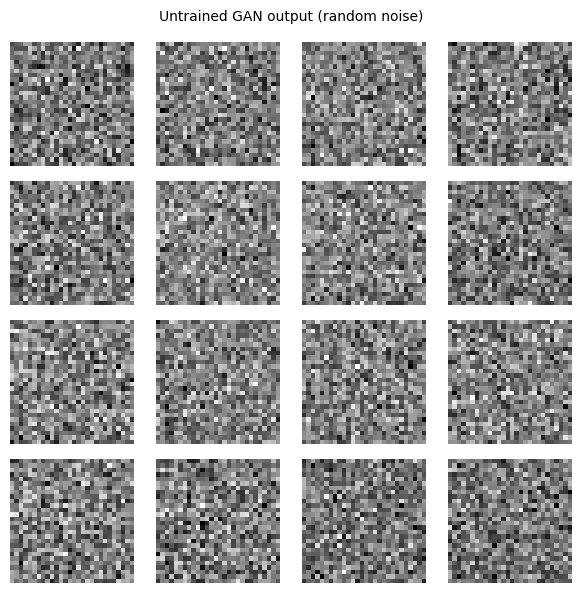

Discriminator scores on first 4 fakes (untrained, ~0.5):
  Image 1: 0.5487
  Image 2: 0.5438
  Image 3: 0.5464
  Image 4: 0.5475


In [17]:
import matplotlib.pyplot as plt

gen  = Generator()
disc = Discriminator()

noise = torch.randn(16, 100)
with torch.no_grad():
    fake_images = gen(noise)

print('Fake image batch shape:', fake_images.shape)

# Show 4x4 grid
imgs = fake_images.reshape(16, 28, 28).numpy()
fig, axes = plt.subplots(4, 4, figsize=(6, 6))
fig.suptitle('Untrained GAN output (random noise)', fontsize=10)
for ax, img in zip(axes.flatten(), imgs):
    ax.imshow(img, cmap='gray')
    ax.axis('off')
plt.tight_layout()
plt.show()

# Test discriminator
with torch.no_grad():
    preds = disc(fake_images)
print('Discriminator scores on first 4 fakes (untrained, ~0.5):')
for i, p in enumerate(preds[:4]):
    print(f'  Image {i+1}: {p.item():.4f}')


**Data Augmentation with GANs:**
Once trained, the Generator can produce synthetic samples to expand a small dataset.
This is especially useful in medical imaging where labeled data is rare.

**When is it risky?** If the GAN suffers from mode collapse (all outputs look the same), synthetic data adds noise not signal. Also, synthetic data can amplify existing biases.


## Section 7: Final Mini Project (Day 7)

**Text Analysis Tool** — combines token counter, summarizer, and sentiment analysis.


In [18]:
from transformers import AutoTokenizer, pipeline

tokenizer = AutoTokenizer.from_pretrained('gpt2')
sentiment  = pipeline('sentiment-analysis')

def count_tokens(text):
    return len(tokenizer.tokenize(text))

def summarize(text, style='bullets'):
    prompts = {
        'bullets': 'Summarize in 3 bullet points:\n',
        'tldr':    'One sentence TL;DR:\n',
    }
    return model.generate_content(prompts[style] + text).text

def analyze(text):
    print('Tokens:   ', count_tokens(text))
    result = sentiment(text[:512])[0]
    print('Sentiment:', result['label'], f"({result['score']:.1%})")
    print('TL;DR:    ', summarize(text, 'tldr'))
    print('Summary:\n', summarize(text, 'bullets'))

sample = '''
Generative AI models like GPT-4 and Gemini are transforming software development and
content creation at an unprecedented pace. While they unlock huge productivity gains,
they also raise serious concerns about hallucination, bias, and job displacement.
Responsible deployment requires transparency and meaningful human oversight.
'''

analyze(sample)


No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f.
Using a pipeline without specifying a model name and revision in production is not recommended.


config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

Tokens:    61
Sentiment: POSITIVE (99.8%)
TL;DR:     Generative AI offers transformative productivity gains for developers and creators, but necessitates careful human oversight to mitigate risks like bias, hallucinations, and workforce displacement.
Summary:
 Here is the summary:

*   **Rapid Transformation:** Generative AI is significantly accelerating the speed of software development and content production.
*   **Key Risks:** The technology introduces critical challenges, including potential bias, factual inaccuracies (hallucination), and the displacement of human workers.
*   **Need for Oversight:** Responsible implementation demands a commitment to transparency and active human supervision.


## Final Reflection

**What did you learn about LLMs?**
LLMs are next-token predictors trained on large text datasets. They are powerful but limited by training cutoffs and hallucination. RAG helps ground their answers in real data.

**What was hardest?**
Building the RAG pipeline from scratch and getting the prompt right so Gemini only answers from context.

**Gemini or Hugging Face — which worked better?**
Gemini was far better for instruction-following tasks. Hugging Face was more useful for offline tasks like tokenization and sentiment analysis.

**Where did models fail?**
GPT-2 produced incoherent answers for direct Q&A since it is a completion model, not instruction-tuned.

**What would you improve?**
Use FAISS for scalable search, train the GAN on MNIST to see real results, and add a Gradio UI to the text analysis tool.


---

# Deliverables
- Notebook completed
- Tokenization outputs compared
- Summarization working
- Chatbot with memory working
- RAG Q&A working
- Final project completed

---

